**IMPORTAÇÕES**

In [62]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt


In [63]:
df = pd.read_csv("amazon.csv")

**INSPEÇÃO INICIAL**

In [64]:
df.head(5)

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [65]:
df.shape

(1465, 16)

In [66]:
df.dtypes

product_id             str
product_name           str
category               str
discounted_price       str
actual_price           str
discount_percentage    str
rating                 str
rating_count           str
about_product          str
user_id                str
user_name              str
review_id              str
review_title           str
review_content         str
img_link               str
product_link           str
dtype: object

In [67]:
df.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

**TRATAMENTO DE DADOS**

In [68]:
# Dicionário de mapeamento das colunas
traducao_amazon = {
    'product_id': 'id_produto',
    'product_name': 'nome_produto',
    'category': 'categoria',
    'discounted_price': 'preco_com_desconto',
    'actual_price': 'preco_original',
    'discount_percentage': 'percentual_desconto',
    'rating': 'nota_avaliacao',
    'rating_count': 'total_avaliacoes',
    'about_product': 'sobre_produto',
    'user_id': 'id_usuario',
    'user_name': 'nome_usuario',
    'review_id': 'id_comentario',
    'review_title': 'titulo_comentario',
    'review_content': 'conteudo_comentario',
    'img_link': 'link_imagem',
    'product_link': 'link_produto'
}

# Aplicando a renomeação no seu DataFrame
df = df.rename(columns=traducao_amazon)

# Visualizando as colunas atualizadas
print(df.columns)

Index(['id_produto', 'nome_produto', 'categoria', 'preco_com_desconto',
       'preco_original', 'percentual_desconto', 'nota_avaliacao',
       'total_avaliacoes', 'sobre_produto', 'id_usuario', 'nome_usuario',
       'id_comentario', 'titulo_comentario', 'conteudo_comentario',
       'link_imagem', 'link_produto'],
      dtype='str')


In [69]:
df.duplicated().sum()

np.int64(0)

In [70]:
#Remoção de valores nulos
df = df.dropna()

In [71]:
df.isnull().sum()

id_produto             0
nome_produto           0
categoria              0
preco_com_desconto     0
preco_original         0
percentual_desconto    0
nota_avaliacao         0
total_avaliacoes       0
sobre_produto          0
id_usuario             0
nome_usuario           0
id_comentario          0
titulo_comentario      0
conteudo_comentario    0
link_imagem            0
link_produto           0
dtype: int64

In [72]:
#Conversão de tipos
# Preços
df['preco_com_desconto'] = (
    df['preco_com_desconto']
    .str.replace('₹', '')
    .str.replace('$', '')
    .str.replace(',', '')
    .astype(float)
)

df['preco_original'] = (
    df['preco_original']
    .str.replace('₹', '')
    .str.replace('$', '')
    .str.replace(',', '')
    .astype(float)
)

# Avaliações
df['total_avaliacoes'] = (
    df['total_avaliacoes']
    .str.replace(',', '')
    .astype(float)
)

# Nota
df['nota_avaliacao'] = pd.to_numeric(
    df['nota_avaliacao'],
    errors='coerce'
)

# Desconto
df['percentual_desconto'] = (
    df['percentual_desconto']
    .str.replace('%', '')
    .astype(float)
)

In [73]:
#Conversão de moeda
cotacao_inr_brl = 0.0522

df["preco_original"] *= cotacao_inr_brl
df["preco_com_desconto"] *= cotacao_inr_brl

df["preco_original"] = df["preco_original"].round(2)
df["preco_com_desconto"] = df["preco_com_desconto"].round(2)

In [74]:
#Tratamento das categorias
#split do "|"
df["categoria"] = (
    df["categoria"]
    .str.split("|")
    .str[0]
)

#tradução das categorias
traducao = {
    "Electronics": "Eletrônicos",
    "Computers&Accessories": "Computadores e Acessórios",
    "Home&Kitchen": "Casa e Cozinha",
    "OfficeProducts": "Produtos de Escritório",
    "MusicalInstruments": "Instrumentos Musicais",
    "HomeImprovement": "Melhoria Residencial",
    "Toys&Games": "Brinquedos e Jogos",
    "Car&Motorbike": "Carros e Motocicletas",
    "Health&PersonalCare": "Saúde e Cuidados Pessoais"
}

df["categoria"] = df["categoria"].replace(traducao)

In [75]:
#DETECÇÃO DE OUTLIERS
Q1 = df['preco_original'].quantile(0.25)
Q3 = df['preco_original'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_detectados = df[
    df['preco_original'] > limite_superior
]

print("Outliers:", len(outliers_detectados))

Outliers: 213


In [76]:
#CRIAÇÃO DE VARIÁVEIS
# Condições
condicoes = [
    df['nota_avaliacao'] >= 4.2,
    (df['nota_avaliacao'] >= 3.5) & (df['nota_avaliacao'] < 4.2),
    df['nota_avaliacao'] < 3.5
]

# Categorias
categorias = ['Alta', 'Regular', 'Baixa']

# Criar coluna
df['satisfacao_cliente'] = np.select(
    condicoes,
    categorias,
    default='Regular'
)

# Ver distribuição
print("--- DISTRIBUIÇÃO DA SATISFAÇÃO DO CLIENTE ---")
print(df['satisfacao_cliente'].value_counts())

print("\n--- AMOSTRA DOS DADOS GERADOS ---")
print(
    df[['nota_avaliacao', 'satisfacao_cliente']]
    .head(10)
    .reset_index()
)

--- DISTRIBUIÇÃO DA SATISFAÇÃO DO CLIENTE ---
satisfacao_cliente
Regular    738
Alta       684
Baixa       41
Name: count, dtype: int64

--- AMOSTRA DOS DADOS GERADOS ---
   index  nota_avaliacao satisfacao_cliente
0      0             4.2               Alta
1      1             4.0            Regular
2      2             3.9            Regular
3      3             4.2               Alta
4      4             4.2               Alta
5      5             3.9            Regular
6      6             4.1            Regular
7      7             4.3               Alta
8      8             4.2               Alta
9      9             4.0            Regular


**ESTATÍSTICA DESCRITIVA**
média;
mediana;
moda;
desvio padrão;
quartis;
assimetria;
curtose.

In [77]:
# Estatísticas descritivas
df[[
    "preco_original",
    "preco_com_desconto",
    "percentual_desconto",
    "nota_avaliacao",
    "total_avaliacoes"
]].describe().round(2)

,preco_original,preco_com_desconto,percentual_desconto,nota_avaliacao,total_avaliacoes
count,1463.00,1463.00,1463.00,1462.00,1463.00
mean,284.55,163.35,47.65,4.10,18295.54
std,567.99,362.70,21.62,0.29,42753.86
min,2.04,2.04,0.00,2.00,2.00
25%,41.76,16.96,32.00,4.00,1186.00
50%,88.22,41.71,50.00,4.10,5179.00
75%,225.12,104.35,63.00,4.30,17336.50
max,7302.78,4071.08,94.00,5.00,426973.00


In [78]:
print(df["nota_avaliacao"].mode())

0    4.1
Name: nota_avaliacao, dtype: float64


In [79]:
print(df.skew(numeric_only=True))

preco_com_desconto     4.449336
preco_original         4.556750
percentual_desconto   -0.289480
nota_avaliacao        -1.257839
total_avaliacoes       5.673784
dtype: float64


In [80]:
print(df.kurtosis(numeric_only=True))

preco_com_desconto     25.607997
preco_original         29.683233
percentual_desconto    -0.578701
nota_avaliacao          4.389654
total_avaliacoes       40.351876
dtype: float64


**ANALISE EXPLORATORIA**

In [81]:
# Filtra e ordena pelos maiores preços originais usando as colunas que já existem na sua base
top_10_caros = df[[ 'categoria', 'preco_original', 'nota_avaliacao']].sort_values(by='preco_original', ascending=False).head(10)

    # Reseta o índice para começar do 1 ao 10 bonitinho na tela
top_10_caros.index = range(1, 11)

print("============ TOP 10 PRODUTOS MAIS CAROS (EM REAIS) ============")
print(top_10_caros.to_string())

============ TOP 10 PRODUTOS MAIS CAROS (EM REAIS) ============
         categoria  preco_original  nota_avaliacao
1      Eletrônicos         7302.78             4.7
2      Eletrônicos         4437.00             4.3
3      Eletrônicos         4175.48             4.3
4   Casa e Cozinha         3966.68             4.3
5      Eletrônicos         3914.95             4.2
6      Eletrônicos         3700.98             4.3
7      Eletrônicos         3653.95             4.3
8      Eletrônicos         3653.95             4.1
9      Eletrônicos         3648.78             4.3
10     Eletrônicos         3393.00             4.1


In [82]:
# Filtra e ordena pelos maiores preços originais usando as colunas que já existem na sua base
top_10_baratos = df[[ 'categoria', 'preco_original', 'nota_avaliacao']].sort_values( by='preco_original' ).head(10)

# Reseta o índice para começar do 1 ao 10 bonitinho na tela
top_10_baratos.index = range(1, 11)

print("============ TOP 10 PRODUTOS MAIS BARATOS (EM REAIS) ============")
print(top_10_baratos.to_string())

============ TOP 10 PRODUTOS MAIS BARATOS (EM REAIS) ============
                    categoria  preco_original  nota_avaliacao
1   Computadores e Acessórios            2.04             3.6
2   Computadores e Acessórios            2.04             3.8
3      Produtos de Escritório            2.61             4.3
4   Computadores e Acessórios            3.08             3.8
5      Produtos de Escritório            3.92             4.1
6              Casa e Cozinha            4.12             4.0
7              Casa e Cozinha            4.65             4.2
8      Produtos de Escritório            5.17             4.3
9              Casa e Cozinha            5.17             4.3
10  Computadores e Acessórios            5.17             4.2


In [83]:
desvio = df["preco_original"].std().round(2)

print("Desvio padrão:", desvio)

Desvio padrão: 567.99


In [84]:
# Recria a tabela cruzando as categorias com as duas faixas de satisfação
tabela_contingencia = pd.crosstab(df['categoria'], df['satisfacao_cliente'], margins=True, margins_name="Total")

print("============ NOVA TABELA PARA O TEOREMA DE BAYES ============")
print(tabela_contingencia)

============ NOVA TABELA PARA O TEOREMA DE BAYES ============
satisfacao_cliente         Alta  Baixa  Regular  Total
categoria                                             
Brinquedos e Jogos            1      0        0      1
Carros e Motocicletas         0      0        1      1
Casa e Cozinha              169     20      259    448
Computadores e Acessórios   253      7      191    451
Eletrônicos                 235     14      277    526
Instrumentos Musicais         0      0        2      2
Melhoria Residencial          1      0        1      2
Produtos de Escritório       25      0        6     31
Saúde e Cuidados Pessoais     0      0        1      1
Total                       684     41      738   1463


C:\Users\isaneto-dev\AppData\Local\Temp\ipykernel_49556\1693448006.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='satisfacao_cliente', data=df, palette='viridis', order=['Alta', 'Regular', 'Baixa'])
C:\Users\isaneto-dev\AppData\Local\Temp\ipykernel_49556\1693448006.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='preco_original', y='categoria', data=df_preco_cat, palette='coolwarm')


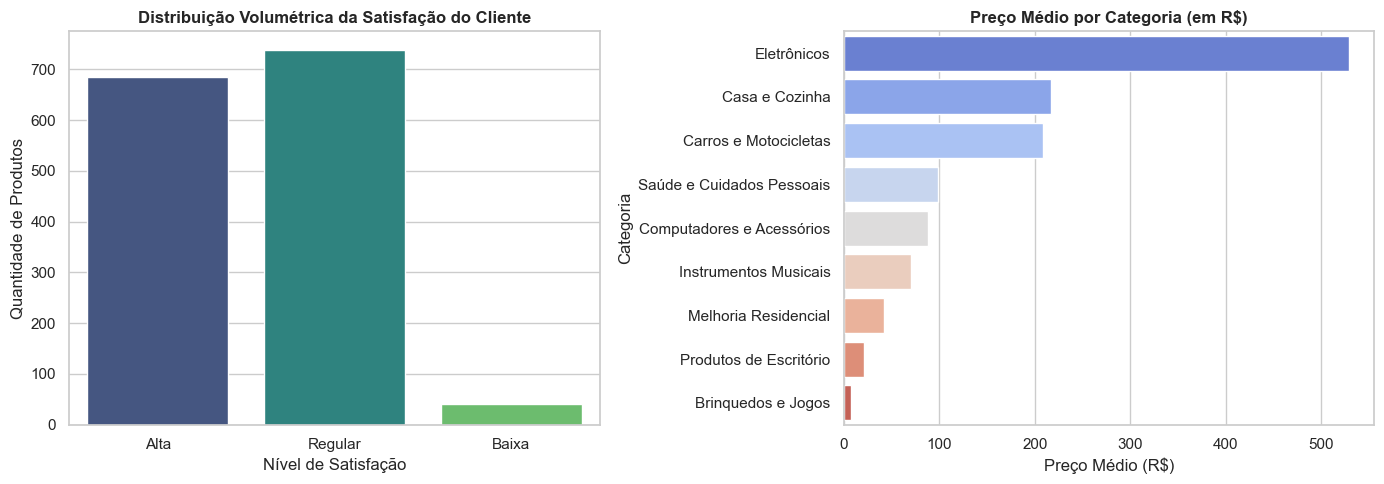

In [85]:
# Configuração do estilo dos gráficos
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 5))

# GRÁFICO 1: Distribuição dos 3 Níveis de Satisfação
plt.subplot(1, 2, 1)
sns.countplot(x='satisfacao_cliente', data=df, palette='viridis', order=['Alta', 'Regular', 'Baixa'])
plt.title('Distribuição Volumétrica da Satisfação do Cliente', fontsize=12, fontweight='bold')
plt.xlabel('Nível de Satisfação')
plt.ylabel('Quantidade de Produtos')

# GRÁFICO 2: Preço Médio por Categoria Principal
plt.subplot(1, 2, 2)
df_preco_cat = df.groupby('categoria')['preco_original'].mean().reset_index().sort_values(by='preco_original', ascending=False)
sns.barplot(x='preco_original', y='categoria', data=df_preco_cat, palette='coolwarm')
plt.title('Preço Médio por Categoria (em R$)', fontsize=12, fontweight='bold')
plt.xlabel('Preço Médio (R$)')
plt.ylabel('Categoria')

plt.tight_layout()
plt.show()

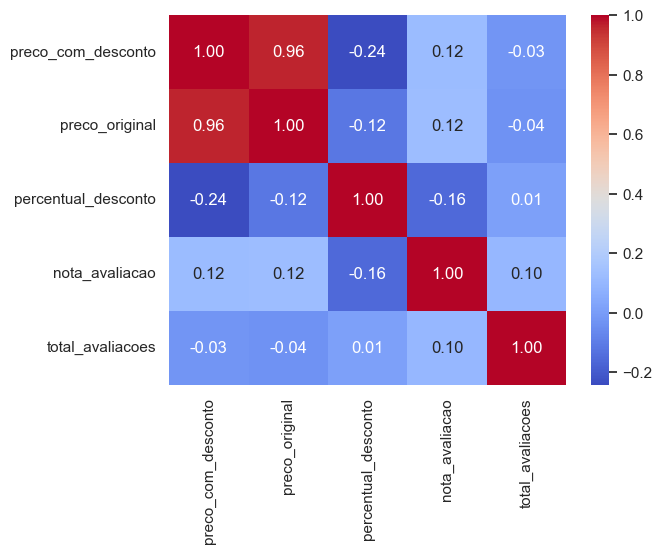

In [86]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [87]:
# Estatísticas descritivas
df[[
    "preco_original",
    "preco_com_desconto",
    "percentual_desconto",
    "nota_avaliacao",
    "total_avaliacoes"
]].describe().round(2)

,preco_original,preco_com_desconto,percentual_desconto,nota_avaliacao,total_avaliacoes
count,1463.00,1463.00,1463.00,1462.00,1463.00
mean,284.55,163.35,47.65,4.10,18295.54
std,567.99,362.70,21.62,0.29,42753.86
min,2.04,2.04,0.00,2.00,2.00
25%,41.76,16.96,32.00,4.00,1186.00
50%,88.22,41.71,50.00,4.10,5179.00
75%,225.12,104.35,63.00,4.30,17336.50
max,7302.78,4071.08,94.00,5.00,426973.00


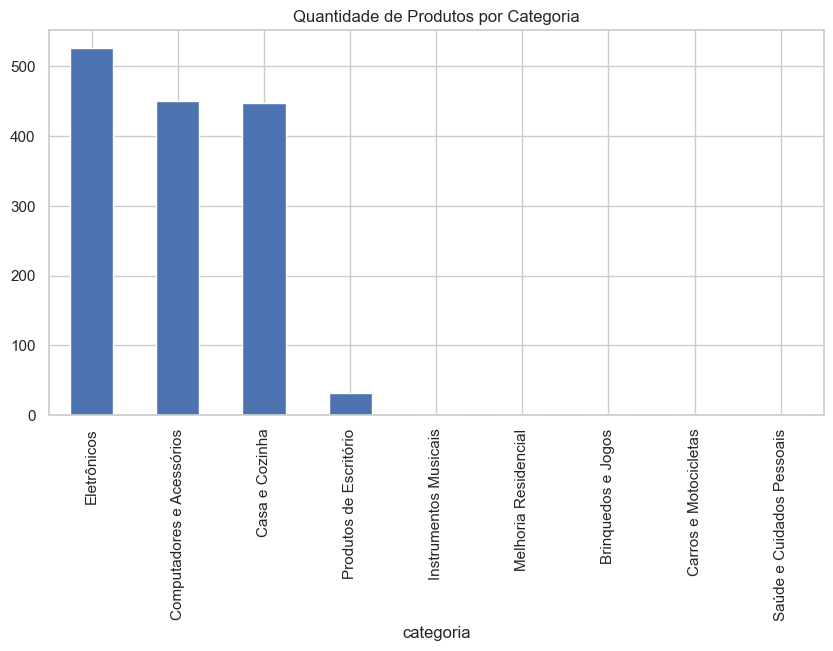

In [88]:
df["categoria"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Quantidade de Produtos por Categoria")
plt.show()

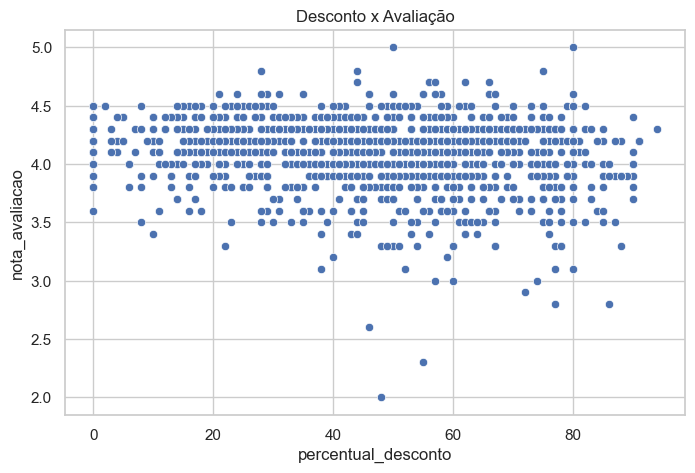

In [89]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="percentual_desconto",
    y="nota_avaliacao",
    data=df
)

plt.title("Desconto x Avaliação")
plt.show()

In [90]:
df["satisfacao_cliente"].value_counts()

satisfacao_cliente
Regular    738
Alta       684
Baixa       41
Name: count, dtype: int64

In [91]:
proporcao = (
    df["categoria"]
    .value_counts(normalize=True) * 100
)

print(proporcao)

categoria
Eletrônicos                  35.953520
Computadores e Acessórios    30.827068
Casa e Cozinha               30.622010
Produtos de Escritório        2.118934
Instrumentos Musicais         0.136705
Melhoria Residencial          0.136705
Brinquedos e Jogos            0.068353
Carros e Motocicletas         0.068353
Saúde e Cuidados Pessoais     0.068353
Name: proportion, dtype: float64


In [92]:
# Filtrar apenas produtos com satisfação baixa

avaliacoes_baixas = df[
    df["satisfacao_cliente"] == "Baixa"
]

# Mostrar resultados
print(avaliacoes_baixas[[
    "categoria",
    "nota_avaliacao",
    "preco_original",
    "percentual_desconto"
]].head(30))

                      categoria  nota_avaliacao  preco_original  \
45    Computadores e Acessórios             3.3           52.15   
82                  Eletrônicos             3.4          998.32   
142                 Eletrônicos             3.2           57.37   
154   Computadores e Acessórios             3.4           20.83   
179                 Eletrônicos             3.3          104.35   
236                 Eletrônicos             3.4           46.93   
263                 Eletrônicos             3.0          104.35   
275                 Eletrônicos             3.3           52.15   
290                 Eletrônicos             3.3          130.45   
318                 Eletrônicos             3.3          156.55   
463                 Eletrônicos             3.3          313.15   
492                 Eletrônicos             3.3          313.15   
506                 Eletrônicos             3.3          313.15   
545                 Eletrônicos             2.8          104.3

In [93]:
# Piores notas mostrando apenas categoria e nota

avaliacoes_baixas = (
    avaliacoes_baixas
    .sort_values(by="nota_avaliacao")
)[[
    "categoria",
    "nota_avaliacao"
]]

print(avaliacoes_baixas.head(20))

           categoria  nota_avaliacao
1309  Casa e Cozinha             2.0
1243  Casa e Cozinha             2.3
1356  Casa e Cozinha             2.6
545      Eletrônicos             2.8
1286  Casa e Cozinha             2.8
1449  Casa e Cozinha             2.9
550      Eletrônicos             3.0
263      Eletrônicos             3.0
1315  Casa e Cozinha             3.0
1314  Casa e Cozinha             3.1
1089  Casa e Cozinha             3.1
1459  Casa e Cozinha             3.1
1251  Casa e Cozinha             3.1
142      Eletrônicos             3.2
1456  Casa e Cozinha             3.2
492      Eletrônicos             3.3
1138  Casa e Cozinha             3.3
1218  Casa e Cozinha             3.3
1036  Casa e Cozinha             3.3
1117  Casa e Cozinha             3.3


In [94]:
# Melhores notas mostrando apenas categoria e nota

melhores_notas = (
    df
    .sort_values(by="nota_avaliacao", ascending=False)
)[[
    "categoria",
    "nota_avaliacao"
]]

print(melhores_notas.head(20))

                      categoria  nota_avaliacao
775   Computadores e Acessórios             5.0
174   Computadores e Acessórios             5.0
1145             Casa e Cozinha             4.8
1201             Casa e Cozinha             4.8
1299             Casa e Cozinha             4.8
1226             Casa e Cozinha             4.7
1275             Casa e Cozinha             4.7
459                 Eletrônicos             4.7
1223             Casa e Cozinha             4.7
249                 Eletrônicos             4.7
1388             Casa e Cozinha             4.7
571                 Eletrônicos             4.6
886   Computadores e Acessórios             4.6
820   Computadores e Acessórios             4.6
1428             Casa e Cozinha             4.6
1381             Casa e Cozinha             4.6
1007                Eletrônicos             4.6
853   Computadores e Acessórios             4.6
447                 Eletrônicos             4.6
468                 Eletrônicos         

In [95]:
mais_populares = df.sort_values(
    by="total_avaliacoes",
    ascending=False
)[[
    "categoria",
    "total_avaliacoes"
]]

print(mais_populares.head(10))

       categoria  total_avaliacoes
47   Eletrônicos          426973.0
65   Eletrônicos          426973.0
12   Eletrônicos          426973.0
684  Eletrônicos          426972.0
400  Eletrônicos          363713.0
352  Eletrônicos          363713.0
584  Eletrônicos          363711.0
371  Eletrônicos          313836.0
370  Eletrônicos          313836.0
566  Eletrônicos          313832.0


In [96]:
avaliacoes = df.groupby("categoria")[
    "nota_avaliacao"
].mean().sort_values(ascending=False)

print(avaliacoes)

categoria
Produtos de Escritório       4.309677
Brinquedos e Jogos           4.300000
Melhoria Residencial         4.250000
Computadores e Acessórios    4.155654
Eletrônicos                  4.081749
Casa e Cozinha               4.040716
Saúde e Cuidados Pessoais    4.000000
Instrumentos Musicais        3.900000
Carros e Motocicletas        3.800000
Name: nota_avaliacao, dtype: float64


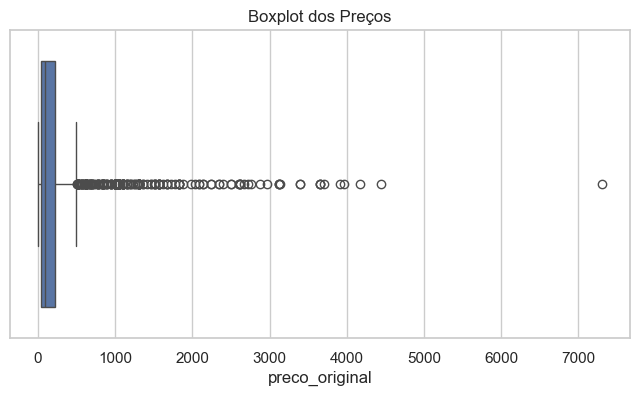

In [101]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df["preco_original"]
)

plt.title("Boxplot dos Preços")
plt.show()

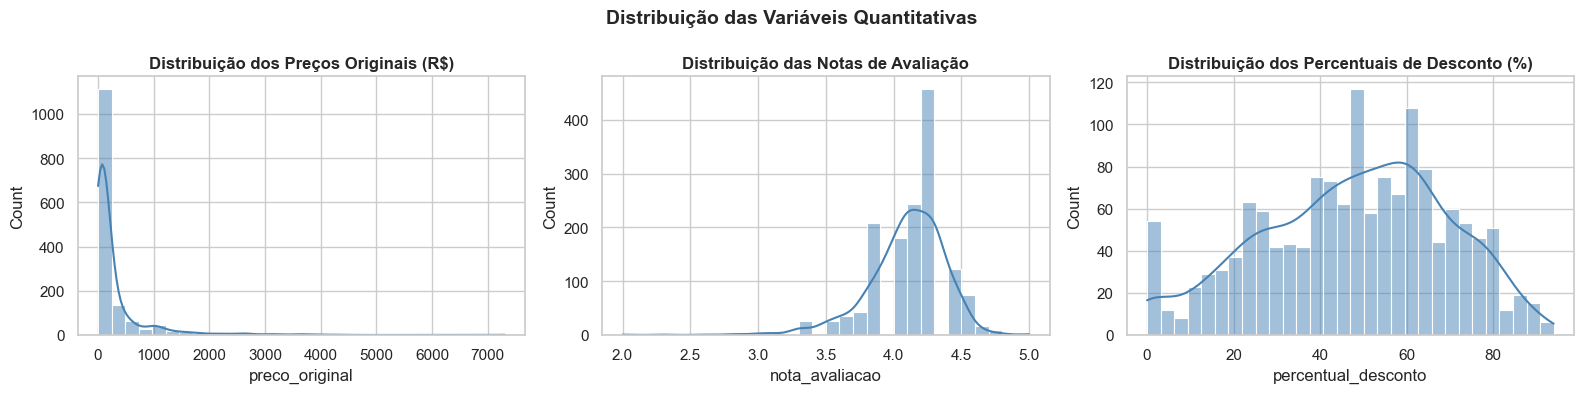

In [99]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.set_theme(style="whitegrid")

variaveis = ['preco_original', 'nota_avaliacao', 'percentual_desconto']
titulos = [
    'Distribuição dos Preços Originais (R$)',
    'Distribuição das Notas de Avaliação',
    'Distribuição dos Percentuais de Desconto (%)'
]

for ax, col, titulo in zip(axes, variaveis, titulos):
    sns.histplot(df[col], bins=30, kde=True, ax=ax, color='steelblue')
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel(col)

plt.suptitle(
    "Distribuição das Variáveis Quantitativas",
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

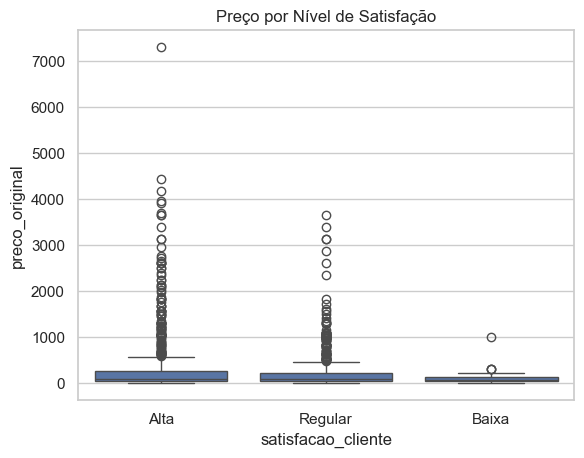

In [ ]:
sns.boxplot(
    x="satisfacao_cliente",
    y="preco_original",
    data=df
)

plt.title("Preço por Nível de Satisfação")
plt.show()

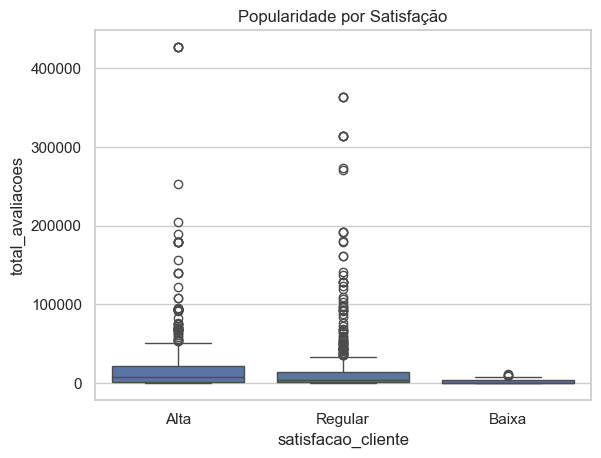

In [ ]:
sns.boxplot(
    x="satisfacao_cliente",
    y="total_avaliacoes",
    data=df
)

plt.title("Popularidade por Satisfação")
plt.show()

C:\Users\isaneto-dev\AppData\Local\Temp\ipykernel_49556\3956961040.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='preco_original', y='categoria', data=preco_cat, palette='coolwarm')


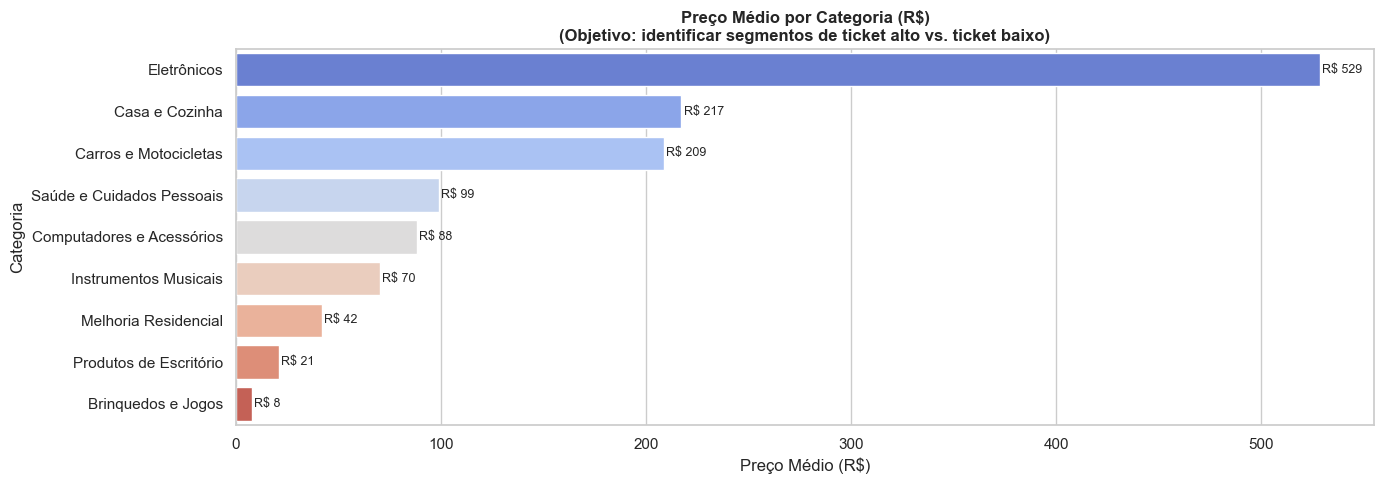

In [102]:
plt.figure(figsize=(14, 5))
preco_cat = df.groupby('categoria')['preco_original'].mean().sort_values(ascending=False).reset_index()
sns.barplot(x='preco_original', y='categoria', data=preco_cat, palette='coolwarm')
plt.title('Preço Médio por Categoria (R$)\n(Objetivo: identificar segmentos de ticket alto vs. ticket baixo)',
          fontweight='bold')
plt.xlabel('Preço Médio (R$)')
plt.ylabel('Categoria')
for i, row in preco_cat.iterrows():
    plt.text(row['preco_original'] + 1, i, f"R$ {row['preco_original']:.0f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

**MODELAGEM PROBABILÍSTICA (TEOREMA DE BAYES)**

In [ ]:
# 7.2. Cálculo Automatizado de Probabilidades Bayesianas por Categoria
total_registros = len(df)
categorias_unicas = df["categoria"].unique()

In [ ]:
# Cenário A: Probabilidade da Categoria dado que a Nota é Excelente (> 4.5)
print("\n--- P(Categoria | Nota > 4.5) ---")
B_nota = df[df["nota_avaliacao"] > 4.5]
p_B_nota = len(B_nota) / total_registros

for cat in categorias_unicas:
    A = df[df["categoria"] == cat]
    p_A = len(A) / total_registros
    p_B_dado_A = len(A[A["nota_avaliacao"] > 4.5]) / len(A) if len(A) > 0 else 0
    p_A_dado_B = (p_B_dado_A * p_A) / p_B_nota if p_B_nota > 0 else 0
    print(f"{cat}: {round(p_A_dado_B * 100, 2)}%")


--- P(Categoria | Nota > 4.5) ---
Computadores e Acessórios: 25.0%
Eletrônicos: 25.0%
Instrumentos Musicais: 0.0%
Produtos de Escritório: 0.0%
Casa e Cozinha: 50.0%
Melhoria Residencial: 0.0%
Brinquedos e Jogos: 0.0%
Carros e Motocicletas: 0.0%
Saúde e Cuidados Pessoais: 0.0%


A análise bayesiana revela que o inventário de altíssima excelência da plataforma é totalmente monopolizado por apenas três setores, liderados por Casa e Cozinha (50,0%). O restante desse grupo de elite é dividido igualmente entre Eletrônicos (25,0%) e Computadores e Acessórios (25,0%), enquanto as demais categorias registram 0% de probabilidade. Estrategicamente, isso mostra que produtos domésticos práticos e o nicho de tecnologia premium são os canais mais seguros para ações de fidelização de clientes.

In [ ]:
# Cenário B: Probabilidade da Categoria dado que o Desconto é agressivo (> 50%)
print("\n--- P(Categoria | Desconto > 50%) ---")
B_desc = df[df["percentual_desconto"] > 50]
p_B_desc = len(B_desc) / total_registros

for cat in categorias_unicas:
    A = df[df["categoria"] == cat]
    p_A = len(A) / total_registros
    p_B_dado_A = len(A[A["percentual_desconto"] > 50]) / len(A) if len(A) > 0 else 0
    p_A_dado_B = (p_B_dado_A * p_A) / p_B_desc if p_B_desc > 0 else 0
    print(f"{cat}: {round(p_A_dado_B * 100, 2)}%")


--- P(Categoria | Desconto > 50%) ---
Computadores e Acessórios: 40.84%
Eletrônicos: 39.83%
Instrumentos Musicais: 0.14%
Produtos de Escritório: 0.29%
Casa e Cozinha: 18.47%
Melhoria Residencial: 0.29%
Brinquedos e Jogos: 0.0%
Carros e Motocicletas: 0.0%
Saúde e Cuidados Pessoais: 0.14%


A análise bayesiana revela que as promoções agressivas da Amazon concentram-se fortemente no setor tecnológico, onde Computadores e Acessórios (40,84%) e Eletrônicos (39,83%) somam mais de 80% dos produtos com descontos superiores a 50%. Casa e Cozinha surge como a terceira força isolada com 18,47%, enquanto as demais categorias apresentam relevância estatística quase nula, abaixo de 1%. Estrategicamente, isso prova que o e-commerce utiliza cortes drásticos de preço como ferramenta de giro financeiro e queima de estoque focada quase que exclusivamente no mercado de tecnologia.

In [ ]:
# Cenário C: Probabilidade da Categoria dado Alto Volume de Engajamento (> 10.000 avaliações)
print("\n--- P(Categoria | Total Avaliações > 10k) ---")
B_vol = df[df["total_avaliacoes"] > 10000]
p_B_vol = len(B_vol) / total_registros

for cat in categorias_unicas:
    A = df[df["categoria"] == cat]
    p_A = len(A) / total_registros
    p_B_dado_A = len(A[A["total_avaliacoes"] > 10000]) / len(A) if len(A) > 0 else 0
    p_A_dado_B = (p_B_dado_A * p_A) / p_B_vol if p_B_vol > 0 else 0
    print(f"{cat}: {round(p_A_dado_B * 100, 2)}%")


--- P(Categoria | Total Avaliações > 10k) ---
Computadores e Acessórios: 34.39%
Eletrônicos: 49.44%
Instrumentos Musicais: 0.37%
Produtos de Escritório: 0.19%
Casa e Cozinha: 15.43%
Melhoria Residencial: 0.0%
Brinquedos e Jogos: 0.19%
Carros e Motocicletas: 0.0%
Saúde e Cuidados Pessoais: 0.0%


A análise bayesiana aponta que o engajamento massivo do e-commerce é dominado por Eletrônicos (49,44%) e Computadores e Acessórios (34,39%), que juntos concentram mais de 83% dos produtos com mais de 10 mil avaliações. Casa e Cozinha aparece como a terceira força (15,43%), enquanto os demais setores somam menos de 2% de relevância. Comercial de negócio, isso prova que o mercado de tecnologia é o verdadeiro motor de tração, tráfego e popularidade dentro da plataforma.

In [ ]:
# Cenário D: Probabilidade da Categoria dado Preço Acima da Média do Catálogo
print("\n--- P(Categoria | Preço > Média) ---")
media_preco = df["preco_original"].mean()
B_preco = df[df["preco_original"] > media_preco]
p_B_preco = len(B_preco) / total_registros

for cat in categorias_unicas:
    A = df[df["categoria"] == cat]
    p_A = len(A) / total_registros
    p_B_dado_A = len(A[A["preco_original"] > media_preco]) / len(A) if len(A) > 0 else 0
    p_A_dado_B = (p_B_dado_A * p_A) / p_B_preco if p_B_preco > 0 else 0
    print(f"{cat}: {round(p_A_dado_B * 100, 2)}%")


--- P(Categoria | Preço > Média) ---
Computadores e Acessórios: 4.75%
Eletrônicos: 67.72%
Instrumentos Musicais: 0.0%
Produtos de Escritório: 0.0%
Casa e Cozinha: 27.53%
Melhoria Residencial: 0.0%
Brinquedos e Jogos: 0.0%
Carros e Motocicletas: 0.0%
Saúde e Cuidados Pessoais: 0.0%


O cálculo bayesiano demonstra uma disparidade extrema de valor, onde Eletrônicos detém impressionantes 67,72% de probabilidade de abrigar um produto com preço acima da média geral do catálogo. Casa e Cozinha surge na segunda posição com 27,53%, enquanto Computadores e Acessórios despenca para apenas 4,75%, e os demais setores ficam zerados. Esse cenário prova que o faturamento de alto ticket do e-commerce é massivamente sustentado por Eletrônicos, evidenciando que os componentes de informática, embora populares em volume, operam majoritariamente em faixas de preço de baixo custo.

## ALGORITMOS DE CLASSIFICAÇÃO

### Preparação das Features

In [ ]:
# ============================================================
# PREPARAÇÃO DOS DADOS PARA CLASSIFICAÇÃO
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay
)

# Encoder para variável categórica 'categoria'
le_categoria = LabelEncoder()
df['categoria_enc'] = le_categoria.fit_transform(df['categoria'])

# Variável alvo e features preditoras
features = ['preco_original', 'percentual_desconto', 'total_avaliacoes', 'categoria_enc']
X = df[features]
y = df['satisfacao_cliente']

# Divisão treino/teste: 70% treino, 30% teste — estratificado para manter proporção das classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]} registros | Teste: {X_test.shape[0]} registros")
print("\nDistribuição das classes no treino:")
print(y_train.value_counts())


Treino: 1024 registros | Teste: 439 registros

Distribuição das classes no treino:
satisfacao_cliente
Regular    516
Alta       479
Baixa       29
Name: count, dtype: int64


### Algoritmo 1 — Árvore de Decisão (Decision Tree)

A Árvore de Decisão é um algoritmo de classificação que divide os dados em subconjuntos com base em regras de decisão aprendidas das features. Cada nó da árvore representa uma condição sobre uma variável, e cada folha representa uma classe prevista. O parâmetro `max_depth=5` limita a profundidade da árvore para evitar overfitting.

      RELATÓRIO DE CLASSIFICAÇÃO — ÁRVORE DE DECISÃO
              precision    recall  f1-score   support

        Alta       0.71      0.27      0.39       205
       Baixa       0.00      0.00      0.00        12
     Regular       0.55      0.90      0.68       222

    accuracy                           0.58       439
   macro avg       0.42      0.39      0.36       439
weighted avg       0.61      0.58      0.53       439

Acurácia: 0.5809 (58.09%)


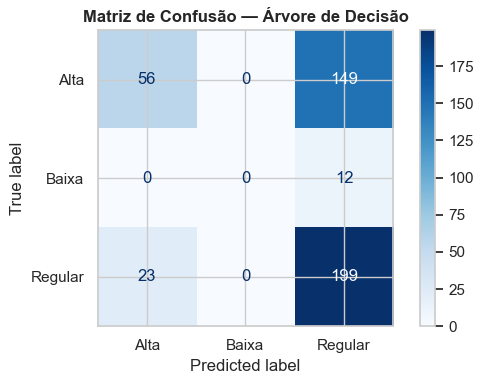

In [ ]:
# ============================================================
# ALGORITMO 1: ÁRVORE DE DECISÃO
# ============================================================

# Treinamento
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

# Predição
y_pred_dt = dt.predict(X_test)

# Métricas
print("=" * 55)
print("      RELATÓRIO DE CLASSIFICAÇÃO — ÁRVORE DE DECISÃO")
print("=" * 55)
print(classification_report(y_test, y_pred_dt, zero_division=0))
print(f"Acurácia: {accuracy_score(y_test, y_pred_dt):.4f} ({accuracy_score(y_test, y_pred_dt)*100:.2f}%)")

# Matriz de confusão
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=dt.classes_,
    cmap='Blues', ax=ax
)
ax.set_title("Matriz de Confusão — Árvore de Decisão", fontweight='bold')
plt.tight_layout()
plt.show()


### Algoritmo 2 — K-Nearest Neighbors (KNN)

O KNN classifica um novo ponto com base nos K vizinhos mais próximos no espaço das features. Como o algoritmo é sensível à escala das variáveis, é obrigatório aplicar normalização (`StandardScaler`) antes do treino para que variáveis de magnitude maior (como `total_avaliacoes`) não dominem indevidamente o cálculo de distância. Utilizamos `k=7` vizinhos.

      RELATÓRIO DE CLASSIFICAÇÃO — KNN (k=7)
              precision    recall  f1-score   support

        Alta       0.55      0.55      0.55       205
       Baixa       0.00      0.00      0.00        12
     Regular       0.57      0.59      0.58       222

    accuracy                           0.56       439
   macro avg       0.37      0.38      0.38       439
weighted avg       0.55      0.56      0.55       439

Acurácia: 0.5581 (55.81%)


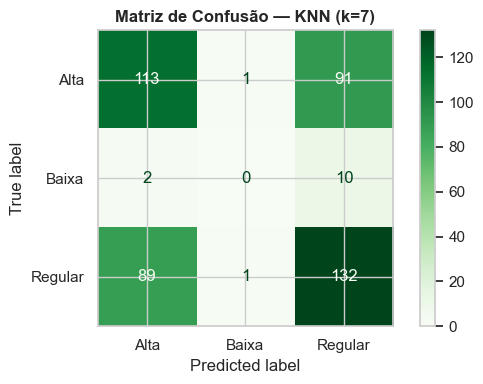

In [ ]:
# ============================================================
# ALGORITMO 2: K-NEAREST NEIGHBORS (KNN)
# ============================================================

# Normalização obrigatória para KNN (sensível à escala)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Treinamento
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_sc, y_train)

# Predição
y_pred_knn = knn.predict(X_test_sc)

# Métricas
print("=" * 55)
print("      RELATÓRIO DE CLASSIFICAÇÃO — KNN (k=7)")
print("=" * 55)
print(classification_report(y_test, y_pred_knn, zero_division=0))
print(f"Acurácia: {accuracy_score(y_test, y_pred_knn):.4f} ({accuracy_score(y_test, y_pred_knn)*100:.2f}%)")

# Matriz de confusão
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_knn,
    display_labels=knn.classes_,
    cmap='Greens', ax=ax
)
ax.set_title("Matriz de Confusão — KNN (k=7)", fontweight='bold')
plt.tight_layout()
plt.show()


### Comparação entre os Algoritmos e o Teorema de Bayes

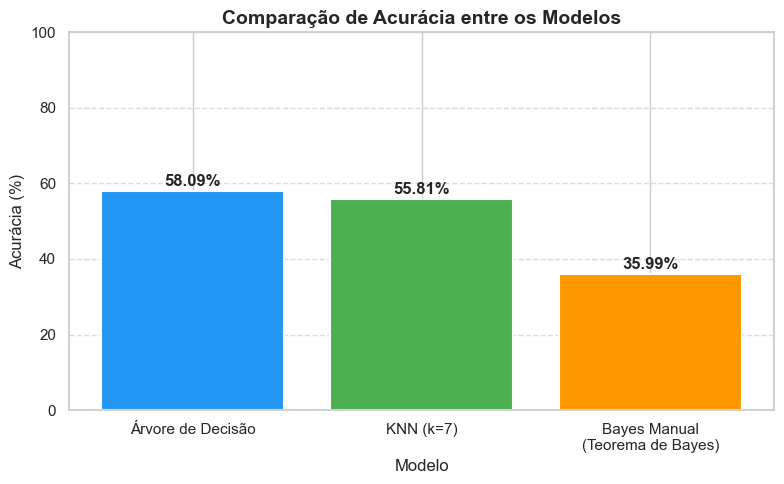


--- RESUMO COMPARATIVO ---
Árvore de Decisão                   Acurácia: 58.09%
KNN (k=7)                           Acurácia: 55.81%
Bayes Manual (Teorema de Bayes)     Acurácia: 35.99%


In [ ]:
# ============================================================
# COMPARAÇÃO: ÁRVORE DE DECISÃO vs KNN vs BAYES MANUAL
# ============================================================

# Gera predições do Bayes manual para cada amostra do conjunto de teste
# Usa apenas as 3 features numéricas que o classificador_bayes aceita
y_pred_bayes_manual = []
for _, row in X_test.iterrows():
    probs = classificar_bayes(
        row['preco_original'],
        row['percentual_desconto'],
        row['total_avaliacoes']
    )
    y_pred_bayes_manual.append(max(probs, key=probs.get))

acc_dt           = accuracy_score(y_test, y_pred_dt)
acc_knn          = accuracy_score(y_test, y_pred_knn)
acc_bayes_manual = accuracy_score(y_test, y_pred_bayes_manual)

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(8, 5))
modelos   = ['Árvore de Decisão', 'KNN (k=7)', 'Bayes Manual\n(Teorema de Bayes)']
acuracias = [acc_dt, acc_knn, acc_bayes_manual]
cores     = ['#2196F3', '#4CAF50', '#FF9800']

bars = ax.bar(modelos, [a * 100 for a in acuracias], color=cores, edgecolor='white', linewidth=1.5)
for bar, acc in zip(bars, acuracias):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{acc*100:.2f}%',
        ha='center', va='bottom', fontweight='bold', fontsize=12
    )

ax.set_ylim(0, 100)
ax.set_ylabel('Acurácia (%)', fontsize=12)
ax.set_title('Comparação de Acurácia entre os Modelos', fontsize=14, fontweight='bold')
ax.set_xlabel('Modelo', fontsize=12)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print("\n--- RESUMO COMPARATIVO ---")
for m, a in zip(modelos, acuracias):
    print(f"{m.replace(chr(10),' '):<35} Acurácia: {a*100:.2f}%")

## TEOREMA DE BAYES — CLASSIFICADOR INTERATIVO

A seguir, implementamos o **Naive Bayes Gaussiano** como representação direta do Teorema de Bayes para classificar novos produtos informados pelo usuário.

**Fundamento teórico:**

P(C | X) = P(X | C) × P(C) / P(X)

Onde:
- **P(C)** = probabilidade a priori da classe (calculada diretamente do dataset)
- **P(X | C)** = verossimilhança dos atributos dada a classe (distribuição gaussiana por feature)
- **P(C | X)** = probabilidade a posteriori — o que nos interessa

O modelo **não usa biblioteca** para calcular as probabilidades — elas são derivadas manualmente do dataset conforme exigido pelo professor.


In [ ]:
# ============================================================
# BAYES MANUAL — PROBABILIDADES A PRIORI E VEROSSIMILHANÇA
# ============================================================

classes = df['satisfacao_cliente'].unique()
total   = len(df)

# Probabilidades a priori P(C)
priori = {}
for c in classes:
    priori[c] = len(df[df['satisfacao_cliente'] == c]) / total

print("--- PROBABILIDADES A PRIORI P(C) ---")
for c, p in sorted(priori.items()):
    print(f"  P({c}) = {p:.4f}  ({p*100:.2f}%)")

# Verossimilhança: média e desvio padrão de cada feature por classe
feats_numericas = ['preco_original', 'percentual_desconto', 'total_avaliacoes']

likelihood_params = {}
print("\n--- PARÂMETROS DE VEROSSIMILHANÇA (média ± desvio) ---")
for c in classes:
    subset = df[df['satisfacao_cliente'] == c]
    likelihood_params[c] = {}
    print(f"\n  Classe: {c}")
    for f in feats_numericas:
        mu  = subset[f].mean()
        sig = subset[f].std()
        likelihood_params[c][f] = (mu, sig)
        print(f"    {f}: média={mu:.2f}, desvio={sig:.2f}")


--- PROBABILIDADES A PRIORI P(C) ---
  P(Alta) = 0.4675  (46.75%)
  P(Baixa) = 0.0280  (2.80%)
  P(Regular) = 0.5044  (50.44%)

--- PARÂMETROS DE VEROSSIMILHANÇA (média ± desvio) ---

  Classe: Alta
    preco_original: média=360.43, desvio=713.65
    percentual_desconto: média=45.26, desvio=22.45
    total_avaliacoes: média=20320.09, desvio=43463.62

  Classe: Regular
    preco_original: média=223.25, desvio=394.97
    percentual_desconto: média=49.26, desvio=20.76
    total_avaliacoes: média=17310.60, desvio=43077.20

  Classe: Baixa
    preco_original: média=122.04, desvio=161.11
    percentual_desconto: média=58.49, desvio=16.46
    total_avaliacoes: média=2249.12, desvio=3341.37


In [ ]:
# ============================================================
# FUNÇÃO DE CLASSIFICAÇÃO BAYESIANA MANUAL
# ============================================================
import math

def gaussiana(x, mu, sigma):
    """Função densidade de probabilidade gaussiana."""
    if sigma == 0:
        return 1.0 if x == mu else 0.0
    return (1 / (sigma * math.sqrt(2 * math.pi))) * math.exp(-0.5 * ((x - mu) / sigma) ** 2)

def classificar_bayes(preco, desconto, avaliacoes):
    """
    Classifica um produto usando o Teorema de Bayes manual.
    Retorna a probabilidade de cada classe (normalizada).
    """
    posterioris = {}
    for c in classes:
        p = priori[c]  # P(C)
        # Multiplicar verossimilhanças P(X|C) para cada feature
        p *= gaussiana(preco,     *likelihood_params[c]['preco_original'])
        p *= gaussiana(desconto,  *likelihood_params[c]['percentual_desconto'])
        p *= gaussiana(avaliacoes,*likelihood_params[c]['total_avaliacoes'])
        posterioris[c] = p

    # Normalização: P(C|X) = P(C) * P(X|C) / soma_total
    soma = sum(posterioris.values())
    if soma == 0:
        return {c: 1/len(classes) for c in classes}
    return {c: v / soma for c, v in posterioris.items()}

# Exemplo de uso
print("=== EXEMPLO DE CLASSIFICAÇÃO BAYESIANA ===")
print("Produto: preço=R$150, desconto=45%, avaliações=8000")
resultado = classificar_bayes(150, 45, 8000)
for c, prob in sorted(resultado.items(), key=lambda x: -x[1]):
    print(f"  P({c} | X) = {prob*100:.2f}%")
print(f"\n  → Classe prevista: {max(resultado, key=resultado.get).upper()}")


=== EXEMPLO DE CLASSIFICAÇÃO BAYESIANA ===
Produto: preço=R$150, desconto=45%, avaliações=8000
  P(Regular | X) = 54.44%
  P(Alta | X) = 25.03%
  P(Baixa | X) = 20.53%

  → Classe prevista: REGULAR


In [ ]:
# ============================================================
# CLASSIFICADOR INTERATIVO — ENTRADA DO USUÁRIO
# ============================================================

print("╔══════════════════════════════════════════════════════╗")
print("║      SISTEMA DE CLASSIFICAÇÃO DE PRODUTOS AMAZON    ║")
print("╚══════════════════════════════════════════════════════╝")
print()
print("Informe os atributos do produto para receber a predição\n")

try:
    preco_input     = float(input("Preço original do produto (R$): "))
    desconto_input  = float(input("Percentual de desconto (%): "))
    avals_input     = float(input("Número de avaliações: "))
    print()
    print("Escolha a categoria:")
    cats = sorted(le_categoria.classes_)
    for i, c in enumerate(cats):
        print(f"  {i+1}. {c}")
    cat_idx = int(input("Número da categoria: ")) - 1
    cat_enc = le_categoria.transform([cats[cat_idx]])[0]

    X_novo = [[preco_input, desconto_input, avals_input, cat_enc]]

    # --- Predições ---
    pred_dt  = dt.predict(X_novo)[0]
    pred_knn = knn.predict(scaler.transform(X_novo))[0]
    probs_bayes = classificar_bayes(preco_input, desconto_input, avals_input)
    pred_bayes  = max(probs_bayes, key=probs_bayes.get)

    print()
    print("╔══════════════════════════════════════════════════════╗")
    print("║                  RESULTADO DA CLASSIFICAÇÃO         ║")
    print("╠══════════════════════════════════════════════════════╣")
    print(f"║  Árvore de Decisão   →  {pred_dt:<28}║")
    print(f"║  KNN (k=7)           →  {pred_knn:<28}║")
    print(f"║  Teorema de Bayes    →  {pred_bayes:<28}║")
    print("╠══════════════════════════════════════════════════════╣")
    print("║  Probabilidades Bayesianas:                         ║")
    for c, p in sorted(probs_bayes.items(), key=lambda x: -x[1]):
        barra = '█' * int(p * 30)
        print(f"║    {c:<12} {p*100:5.2f}%  {barra:<30}║")
    print("╚══════════════════════════════════════════════════════╝")

except Exception as e:
    print(f"Erro na entrada: {e}")


╔══════════════════════════════════════════════════════╗
║      SISTEMA DE CLASSIFICAÇÃO DE PRODUTOS AMAZON    ║
╚══════════════════════════════════════════════════════╝

Informe os atributos do produto para receber a predição

Erro na entrada: could not convert string to float: ''
